In [22]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

Loading line from dict:   0%|          | 0/9944 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9944 [00:00<?, ?it/s]

                                             
Optimize - start penalty: 28.31         
Matching: model call n. 13               
Optimize - end penalty:  4.49385e-06
                                             
Optimize - start penalty: 0.01          
Matching: model call n. 13               
Optimize - end penalty:  2.24769e-10
Target status:                           
id state tag         tol_met       residue   current_val    target_val description                                 
0  ON    qf.42210_x     True  -1.18463e-11  -1.18463e-11             0 ('x', 'qf.42210'), val=0, tol=1e-09, wei ...
1  ON    qf.42210_px    True  -4.52649e-14  -4.52649e-14             0 ('px', 'qf.42210'), val=0, tol=1e-09, we ...
2  ON    qd.41510_x     True  -1.30345e-11  -1.30345e-11             0 ('x', 'qd.41510'), val=0, tol=1e-09, wei ...
3  ON    qd.41510_px    True   1.55722e-13   1.55722e-13             0 ('px', 'qd.41510'), val=0, tol=1e-09, we ...
4  ON    teca_x         True    1.3869e-11    

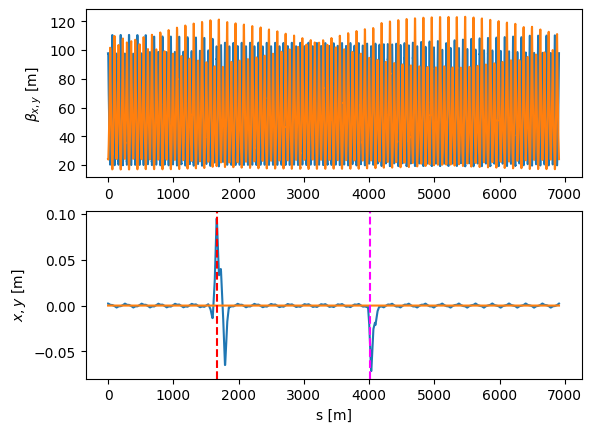

VarsTable: 378 rows, 3 cols
name             value expr
t_turn_s             0 None
version          50900 None
pi             3.14159 None
twopi          6.28319 None
degrad         57.2958 None
raddeg       0.0174533 None
e              2.71828 None
amu0       1.25664e-06 None
emass      0.000510999 None
mumass        0.105658 None
...
kloe63602                             0 None                                
kmdh63607                             0 None                                
v200                                  0 None                                
freq200                           2e+08 None                                
lag200                              180 None                                
kmplh41658_from_bump_teca   -0.00101412 (1.843846579130277e-05 * bump_teca) 
kmplh41994_from_bump_teca  -0.000770381 (1.4006924127077096e-05 * bump_teca)
kmpsh41402_from_bump_teca   3.19553e-12 (-5.810054159517435e-14 * bump_teca)
kmpsh42198_from_bump_teca   -0.00023621 (4.2

In [1]:
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc


from elements import *
from optimisers import *

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4

context = xo.ContextCpu()
# context = xo.ContextCupy()

septum_aperture_size = 68e-3

line: xt.Line = xt.Line.from_json(
    "../database/sps_for_sx.json"
)

Strategy = xt.slicing.Strategy
Teapot = xt.slicing.Teapot

"""
zs_info = dict(
    first_wire_position=68e-3,
    length=18.77,
    last_wire_position=43.3e-3,
    width=400e-6,
    kick=0.363e-3,
    max_aperture_x=100e-3,
    aperture_y=23e-3,
    gap=20e-3,
)


zs_aperture_start = xt.LimitRect(
    max_x=zs_info["first_wire_position"],
    min_x=-zs_info["max_aperture_x"],
    max_y=zs_info["aperture_y"],
    min_y=-zs_info["aperture_y"],
)

zs_aperture_end = xt.LimitRect(
    max_x=zs_info["last_wire_position"],
    min_x=-zs_info["max_aperture_x"],
    max_y=zs_info["aperture_y"],
    min_y=-zs_info["aperture_y"],
)

line.insert_element(
    name="zs_start", element=zs_aperture_start, index="ap.up.zs21633"
)
line.insert_element(
    name="zs_end", element=zs_aperture_end, index="ap.do.zs21676"
)
line.insert_element(name="teca", element=xt.Marker(), at_s=4022)
#line.cycle("zs_start", inplace=True)
line.build_tracker(_context=context)
""" 
line.insert_element(name="teca", element=xt.Marker(), at_s=4022)


# Switch on extraction bump
line.vv["extr_bump_knob"] = 1.0

# Extraction tunes
opt = line.match(
    solve=False,
    vary=[
        xt.VaryList(["kqf", "kqd"], step=1e-7),
        xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4),
    ],
    targets=[
        xt.TargetSet(qx=26.666666666, qy=26.58, tol=1e-5),
        xt.TargetSet(dqx=-1 * 26.0, dqy=0.47 * 26.0, tol=1e-3),
    ],
)

opt.solve()

# Switch on extraction sextupoles
line.vv["sps_on_extraction"] = 1.0

line.vv["extr_bump_knob"] = 0

list(filter(lambda x: "mplh4" in x, line.vars.get_table()["name"]))

# LSA values
# line.vars["kmplh41658"] = 1.8438149615056823e-5
# line.vars["kmplh41994"] = 1.4030353810447943e-5
# line.vars["kmpsh41402"] = -1.0627266158780122e-14
# line.vars["kmpsh42198"] = 4.31417352302254e-6

""" 
opt = line.match_knob(
    knob_name="bump_teca",
    run=False,
    vary=[
        xt.VaryList(
            [
                "kmplh41658",
                "kmplh41994",
                "kmpsh41402",
                "kmpsh42198",
            ],
            step=1e-6,
        )
    ],
    targets=[
        xt.TargetSet(["x", "px"], 0.0, at="qf.42210"),
        xt.TargetSet(["x", "px"], 0.0, at="qd.41510"),
        xt.Target("x", 1e-3, at="teca"),
        #xt.Target("px", TECA.tilt, at="teca"),
    ],
)
 
opt = line.match_knob(
    knob_name="bump_angle_teca",
    run=False,
    vary=[
        xt.VaryList(
            [
                "kmplh41658",
                "kmplh41994",
                "kmpsh41402",
                "kmpsh42198",
            ],
            step=1e-6,
        )
    ],
    targets=[
        xt.TargetSet(["x", "px"], 0.0, at="qf.42210"),
        xt.TargetSet(["x", "px"], 0.0, at="qd.41510"),
        #xt.Target("x", 1e-3, at="teca"),
        xt.Target("px", 1e-3, at="teca"),
    ],
)
"""

opt = line.match_knob(
    knob_name="bump_teca",
    run=False,
    vary=[
        xt.VaryList(
            [
                "kmplh41658",
                "kmplh41994",
                "kmpsh41402",
                "kmpsh42198",
            ],
            step=1e-6,
        )
    ],
    targets=[
        xt.TargetSet(["x", "px"], 0.0, at="qf.42210"),
        xt.TargetSet(["x", "px"], 0.0, at="qd.41510"),
        xt.Target("x", 1e-3, at="teca"),
        #xt.Target("px", 1e-3, at="teca"),
    ],
)

opt.log()
opt.solve()
opt.target_status()
opt.vary_status()

opt.generate_knob()

opt.get_knob_values()


line.vv["extr_bump_knob"] = 1.98
line.vv["sps_on_extraction"] = 1.0
line.vars["bump_teca"] = -55



#line.vars["extr_bump_knob"] = 2
#line.vars["bump_teca"] = - 1.23
#line.vv["sps_on_extraction"] = 2.0



#line.vars["bump_teca"] = -55
#line.vars["bump_angle_teca"] = - 1.23
#line.vars["extr_bump_knob"] = 0


# tab = line.get_table(attr=True)
# line.vars.get_table()
# tab.rows["mp.h\.4.*"].cols["k0l"]

# bumpers = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)
# line
# line.info("bump_teca")

tw = line.twiss(continue_on_closed_orbit_error=True)

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
plt.plot(tw.s, tw.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x)
plt.plot(tw.s, tw.y)
plt.axvline(tw["s", "zs.21633_entry"], color="red", ls="--")
plt.axvline(tw["s", "teca"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()

n_part = 200

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP

particles: xt.Particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

line_df = line.to_pandas()

line.vars.get_table()


In [2]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.4.*"].cols["k0l"]

bumpers = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)
#line
line.info("bump_teca")

#  vars['bump_teca']._get_value()
   vars['bump_teca'] = -55

#  vars['bump_teca']._expr is None

#  vars['bump_teca']._find_dependant_targets()
   vars['kmpsh42198_from_bump_teca']
   vars['kmpsh42198']
   element_refs['mpsh.42198'].knl[0]
   vars['kmpsh41402_from_bump_teca']
   vars['kmpsh41402']
   element_refs['mpsh.41402'].knl[0]
   vars['kmplh41994_from_bump_teca']
   vars['kmplh41994']
   element_refs['mplh.41994'].knl[0]
   vars['kmplh41658_from_bump_teca']
   vars['kmplh41658']
   element_refs['mplh.41658'].knl[0]



# Selecting the tune and matching the desired optics

In [3]:
from elements import *
from optimisers import *

In [4]:
tune = 24.39

In [5]:
line.build_tracker(_context=context)

optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

line.discard_tracker()


The line already has an associated tracker
                                             
Optimize - start penalty: 31.23         
Matching: model call n. 19               
Optimize - end penalty:  6.23865e-06
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True  -1.06557e-07         24.39         24.39 'qx', val=24.39, tol=1e-05, weight=10
1  ON    qy     True   6.14698e-07         24.44         24.44 'qy', val=24.44, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0136684 None            0.0146633         1e-07             1
1  ON        OK  kqd          None            -0.013648 None           -0.0146233         1e-07             1
2  ON        OK  qph_setvalue None            -0.972816 None            -0.972816     

### Plotting the twiss parameters after rematching the tunes

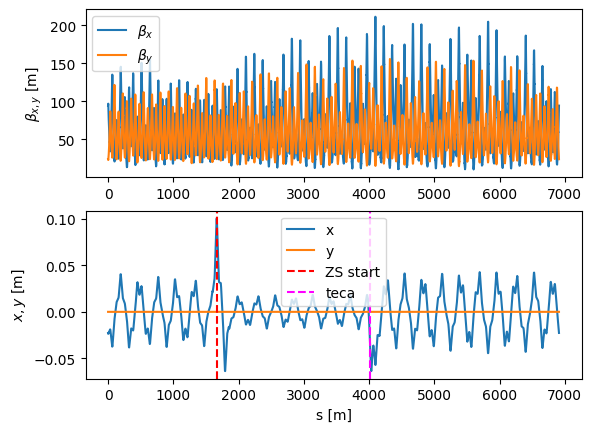

In [6]:
tw = line.twiss(continue_on_closed_orbit_error=True)
tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx, label=r"$\beta_x$")
plt.plot(tw.s, tw.bety, label=r"$\beta_y$")
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.legend()

ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x, label="x")
plt.plot(tw.s, tw.y, label="y")
plt.axvline(tw["s", "zs.21633_entry"], color="red", ls="--", label='ZS start')
plt.axvline(tw["s", "teca"], color="magenta", ls="--", label='teca')
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.legend()
plt.show()

# Checking that the line doesn't block the particle

Inserting some markers so that the different codes can work properly together

In [7]:
# CHANGE THE VALUES OF S WITH "FROM S" AND "TO S" BECAUSE IF YOU CYCLE 
# THE LINE IT IS NOT CORRECT THE POSITION OF THE ELEMENTS

line.discard_tracker()
# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)

#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)



Slicing line:   0%|          | 0/9946 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9949 [00:00<?, ?it/s]

In [8]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760']
tcsm_position = line.get_table()['s', 'tcsm.51932']


In [9]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)

Non-channeled particle not lost during tracking.
The line already has an associated tracker
Channeled particle not lost during tracking.
Blocking elements encountered:


In [10]:
remove_ZS_apertures(line)

In [11]:
remove_inner_sideLimits_closeTECA(line)

In [12]:
save_df_Limit_elements_features(line)

Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []


,Position,Element Name,max_x,min_x


# Installing the septa

In [13]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


In [14]:
df_elements = save_df_Limit_elements_features(line)

Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []


In [15]:
tw = line.twiss(x = 0, px = 0, method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
# tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')

bg = line.particle_ref._gamma0[0]*line.particle_ref._beta0[0]  #this line is calculating the relativistic quantity Beta Gamma for the reference particle in the line
sigma_x = lambda bet, d, n_sigma=1, bg=bg, dpp=deltaP_P, eps=N_EX: np.sqrt(bet*eps/bg + (d*dpp)**2)*n_sigma  #computing the the BEAM SIZE at a given location

tab = line.get_table()
 

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


# Tracking the particles

Building the particles

In [16]:
n_part = 100

x_norm   = np.random.normal(loc = 0, scale = 2e-3, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 75e-6, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P
 
line.build_tracker() 
 
particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']
tw_lss2 = tw.rows[:]


The line already has an associated tracker
The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Inserting the monitors in order to plot the trajectories

In [17]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
#tw_lss2_df = tw_lss2_df.loc['qd.20910':'qda.21910'] 
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    

Inserting the crystals only now: if the crystals were inserted before the twiss computations would not work and also the optimisers would fail while looking for a closed orbit.

In [18]:
line.discard_tracker()
line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/14111 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/14112 [00:00<?, ?it/s]

<Line  at 4602909776>

In [19]:
num_turns = 100

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 9


/Users/matteogiacomelli/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/matteogiacomelli/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


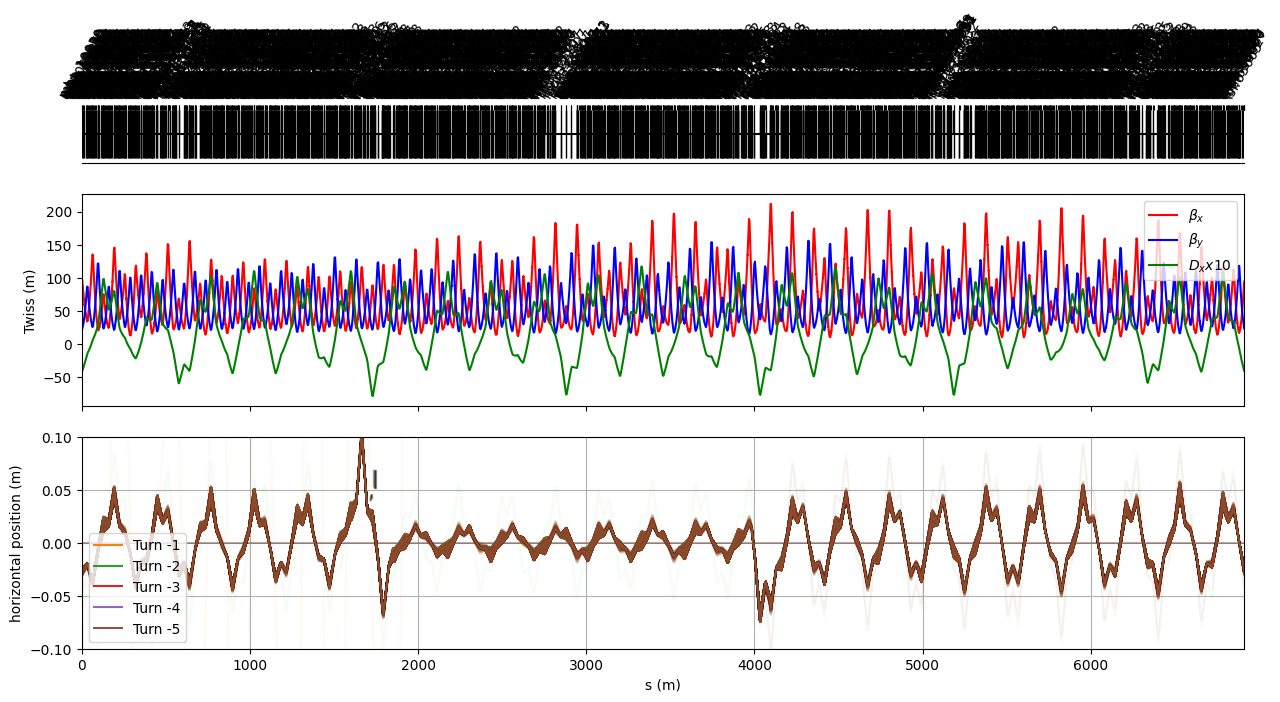

In [20]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')
fig.axes[2].set_ylim(-0.1, 0.1)

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
#fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        color = 'red'
        alpha = 1.0
    # Rectangle from min_x to bottom
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_max)
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 5

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend()

# Plotting phase space at TECA

Text(0, 0.5, "$x'$ (mrad)")

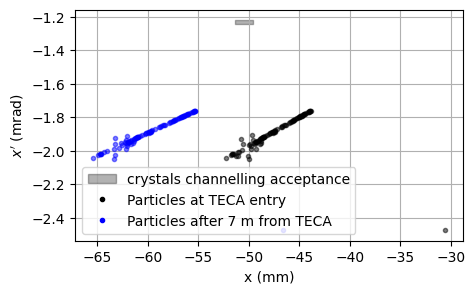

In [21]:
row_TECA_enty = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['tpsc4.41797_entry']


fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(row_TECA_enty['monitors'].x[:, 5] * 1e3, row_TECA_enty['monitors'].px[:, 5] * 1e3, 'k.', alpha=0.5)
ax.plot(row_TECA_exit['monitors'].x[:, 5] * 1e3, row_TECA_exit['monitors'].px[:, 5] * 1e3, 'b.', alpha=0.5)

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')




ax.plot([], [], 'k.', label='Particles at TECA entry')
ax.plot([], [], 'b.', label='Particles after 7 m from TECA')


ax.legend()
ax.grid(True)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")